# Consumo de energía en edificios municipales. Datos mensuales

La información existente en este conjunto de datos proviene de las bases de datos del servicio de seguimiento energético avanzado realizado en el ámbito del Acuerdo Marco de Servicios Energéticos en Instalaciones del Ayuntamiento de Madrid y sus Organismos Autónomos.

En este contexto, y sin perjuicio del seguimiento y control de la facturación energética en la totalidad de edificios municipales, se instalan sensores de consumo energético en algunos de ellos -los que registran mayor consumo, en los que este presenta mayor variabilidad, los que están incluidos en programas específicos de certificación energética o aquellos que cuyas características técnicas u operativas así lo aconsejan- para su supervisión continua y actuación inmediata en caso de incidencia.

### Importar pandas y leer el archivo csv

In [1]:
import pandas as pd

In [2]:
from pathlib import Path

# Si el CSV está descargado junto al notebook se usa ese; si no, se descarga del portal
# (el Ayuntamiento cambia a veces la dirección del archivo).
CSV_LOCAL = Path('consumo_energia_edificios.csv')
CSV_URL = "https://datos.madrid.es/dataset/300430-0-consumo-energia-edificios/resource/300430-0-consumo-energia-edificios-csv/download/300430-0-consumo-energia-edificios-csv.csv"
fuente = CSV_LOCAL if CSV_LOCAL.exists() else CSV_URL

df_rawdata = pd.read_csv(fuente, sep=';', header='infer', decimal=',', encoding='utf-8-sig', low_memory=False)

In [3]:
df_rawdata.head()

,AÑO,MES,ID,TIPOEDIFICIO,EDIFICIO,DIRECCION,DISTRITO,CÓDIGO DISTRITO,BARRIO,CÓDIGO BARRIO,COORDENADA-X,COORDENADA-Y,LONGITUD,LATITUD,SENSOR,TIPO,CLASE,GRUPO,UNIDADES,CONSUMO
0,2020,3,2258.0,Centros culturales y bibliotecas,Biblioteca Ana María Matute,"CALLE ISAAC ALBENIZ, 1 28019 MADRID",CARABANCHEL,11,SAN ISIDRO,113,"438873,92","4472154,36",-3.7202936410904,40.3977521494866,AMBIBAMMATUTE_General,Externo,Energía activa,Activa Interruptor Gral,kWh,13099
1,2020,3,2258.0,Centros culturales y bibliotecas,Biblioteca Ana María Matute,"CALLE ISAAC ALBENIZ, 1 28019 MADRID",CARABANCHEL,11,SAN ISIDRO,113,"438873,92","4472154,36",-3.7202936410904,40.3977521494866,AMBIBAMMATUTE_General,Externo,Energía Reactiva,Reactiva tarifa 3.1A,kvarh,104
2,2020,3,2178.0,Centros culturales y bibliotecas,Biblioteca Ángel González,"CALLE GRANJA DE TORREHERMOSA, 1 28024 MADRID",LATINA,10,ALUCHE,104,"434962,85","4472100,21",-3.7663713097572,40.3969681670062,AMBIBAGONZALEZ_Electricidad_General,Externo,Energía activa,Activa Interruptor Gral,kWh,9688
3,2020,3,2178.0,Centros culturales y bibliotecas,Biblioteca Ángel González,"CALLE GRANJA DE TORREHERMOSA, 1 28024 MADRID",LATINA,10,ALUCHE,104,"434962,85","4472100,21",-3.7663713097572,40.3969681670062,AMBIBAGONZALEZ_Electricidad_General,Externo,Energía Reactiva,Reactiva tarifa 3.1A,kvarh,4262
4,2020,3,2178.0,Centros culturales y bibliotecas,Biblioteca Ángel González,"CALLE GRANJA DE TORREHERMOSA, 1 28024 MADRID",LATINA,10,ALUCHE,104,"434962,85","4472100,21",-3.7663713097572,40.3969681670062,AMBIBAGONZALEZ_Gas_General,Externo,Gas,Gas,m3,0


In [4]:
df_rawdata.info()

<class 'pandas.DataFrame'>
RangeIndex: 35412 entries, 0 to 35411
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AÑO              35412 non-null  int64  
 1   MES              35412 non-null  int64  
 2   ID               12329 non-null  float64
 3   TIPOEDIFICIO     35412 non-null  str    
 4   EDIFICIO         35412 non-null  str    
 5   DIRECCION        35409 non-null  str    
 6   DISTRITO         35412 non-null  str    
 7   CÓDIGO DISTRITO  35412 non-null  str    
 8   BARRIO           35410 non-null  str    
 9   CÓDIGO BARRIO    35412 non-null  str    
 10  COORDENADA-X     35412 non-null  str    
 11  COORDENADA-Y     35412 non-null  str    
 12  LONGITUD         35410 non-null  str    
 13  LATITUD          35412 non-null  str    
 14  SENSOR           35412 non-null  str    
 15  TIPO             35412 non-null  str    
 16  CLASE            35412 non-null  str    
 17  GRUPO            3006 n

In [5]:
df_rawdata.describe(include ='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AÑO,35412.0,NaN,NaN,NaN,2023.485739,1.640847,2020.0,2022.0,2024.0,2025.0,2026.0
MES,35412.0,NaN,NaN,NaN,6.382949,3.404112,1.0,3.0,6.0,9.0,12.0
ID,12329.0,NaN,NaN,NaN,927.04607,786.512377,0.0,97.0,906.0,1771.0,2520.0
TIPOEDIFICIO,35412,11,Centros culturales y bibliotecas,10919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EDIFICIO,35412,245,CDM Aluche,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DIRECCION,35409,227,"CALLE TREVIANA, 1 28043 MADRID",448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISTRITO,35412,23,CENTRO,2971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CÓDIGO DISTRITO,35412,23,1,2971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BARRIO,35410,94,PALACIO,1389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CÓDIGO BARRIO,35412,95,11,1389,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1: Se realiza un filtrado de la base para trabajar y conocer el consumo energético electrico anual por distrito

In [6]:
df_consumo = df_rawdata[['AÑO','DISTRITO','CLASE','GRUPO','UNIDADES','CONSUMO']].sort_values(by='AÑO')
# Solo lecturas eléctricas (kWh) de distritos reales: el origen trae alguna fila con 'PROCESADO' o '#N/D'
df_filtrado = df_consumo[(df_consumo['UNIDADES'] == 'kWh') & ~df_consumo['DISTRITO'].isin(['PROCESADO', '#N/D'])].copy()
df_filtrado

,AÑO,DISTRITO,CLASE,GRUPO,UNIDADES,CONSUMO
0,2020,CARABANCHEL,Energía activa,Activa Interruptor Gral,kWh,13099
2,2020,LATINA,Energía activa,Activa Interruptor Gral,kWh,9688
5,2020,RETIRO,Energía activa,Activa Interruptor Gral,kWh,14630
8,2020,VILLA DE VALLECAS,Energía activa,Activa Interruptor Gral,kWh,4308
11,2020,SAN BLAS - CANILLEJAS,Energía activa,Activa Interruptor Gral,kWh,2751
...,...,...,...,...,...,...
35407,2026,FUENCARRAL - EL PARDO,Energía activa,NaN,kWh,"547,3023071"
35408,2026,MORATALAZ,Energía activa,NaN,kWh,"3341,500732"
35409,2026,FUENCARRAL - EL PARDO,Energía activa,NaN,kWh,"6265,103516"
35410,2026,MORATALAZ,Energía activa,NaN,kWh,"14303,04688"


### 2 y 4: Agregar una columna al agrupar distrito y año para conocer la normalizacion del consumo anual por distrito

In [7]:
# Primero, crear una copia explícita para evitar el warning
df_filtrado = df_filtrado.copy()

# Función para limpiar y convertir la columna CONSUMO
def limpiar_y_convertir_consumo(serie):
    serie_limpia = serie.astype(str).str.strip()
    
    # Reemplazar valores no numéricos por NaN
    valores_invalidos = ['NO DATA', 'NO DATA PROC', '(No hay datos)', 
                        'SIN DATOS O INFORMACIÓN INCOMPLETA', 'nan']
    for val in valores_invalidos:
        serie_limpia = serie_limpia.replace(val, pd.NA)
    
    # Reemplazar coma decimal por punto
    serie_limpia = serie_limpia.str.replace(',', '.', regex=False)
    
    # Convertir a numérico
    return pd.to_numeric(serie_limpia, errors='coerce')

# Aplicar la función de limpieza
df_filtrado['CONSUMO'] = limpiar_y_convertir_consumo(df_filtrado['CONSUMO'])

# Verificar la conversión
print(f"Valores convertidos exitosamente: {df_filtrado['CONSUMO'].notna().sum()}")
print(f"Total de registros: {len(df_filtrado)}")
print(f"Valores NaN: {df_filtrado['CONSUMO'].isna().sum()}")

# Los consumos negativos son errores de lectura del contador: se descartan antes de normalizar
negativos = (df_filtrado['CONSUMO'] < 0).sum()
df_filtrado = df_filtrado[~(df_filtrado['CONSUMO'] < 0)]
print(f"Lecturas negativas descartadas: {negativos}")

# Normalización (z-score) del consumo dentro de cada distrito y año
df_filtrado['CONSUMO_NORM'] = df_filtrado.groupby(['DISTRITO', 'AÑO'])['CONSUMO'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Mostrar resultado
df_filtrado[['DISTRITO', 'AÑO', 'CONSUMO', 'CONSUMO_NORM']]

Valores convertidos exitosamente: 15846
Total de registros: 21368
Valores NaN: 5522
Lecturas negativas descartadas: 3


,DISTRITO,AÑO,CONSUMO,CONSUMO_NORM
0,CARABANCHEL,2020,13099.000000,0.902867
2,LATINA,2020,9688.000000,-0.506494
5,RETIRO,2020,14630.000000,-0.981349
8,VILLA DE VALLECAS,2020,4308.000000,-0.969846
11,SAN BLAS - CANILLEJAS,2020,2751.000000,-0.649141
...,...,...,...,...
35407,FUENCARRAL - EL PARDO,2026,547.302307,-0.915470
35408,MORATALAZ,2026,3341.500732,-0.389353
35409,FUENCARRAL - EL PARDO,2026,6265.103516,-0.653370
35410,MORATALAZ,2026,14303.046880,-0.180776


### 3: Se agrega sort value para encontrar los distritos con los edificios más eficientes (menor consumo normalizado)

In [8]:
df_eficientes = df_filtrado.sort_values(by='CONSUMO_NORM')
df_eficientes

,AÑO,DISTRITO,CLASE,GRUPO,UNIDADES,CONSUMO,CONSUMO_NORM
360,2020,VILLAVERDE,Energía activa,Activa Interruptor Gral,kWh,18435.000000,-2.210363
527,2020,CHAMBERI,Energía activa,Activa Interruptor Gral,kWh,174.200000,-1.682065
1786,2021,TETUAN,Energía activa,NaN,kWh,429.000000,-1.579506
20716,2024,CHAMBERI,Gas,NaN,kWh,0.044924,-1.461970
9850,2022,CHAMBERI,Energía activa,NaN,kWh,10.001986,-1.431219
...,...,...,...,...,...,...,...
35385,2026,CHAMBERI,Gas,NaN,kWh,NaN,NaN
35386,2026,CIUDAD LINEAL,Gas,NaN,kWh,NaN,NaN
35387,2026,HORTALEZA,Gas,NaN,kWh,NaN,NaN
35388,2026,LATINA,Gas,NaN,kWh,NaN,NaN


### 5: Identificar nulos y descartar las lecturas sin consumo

In [9]:
df_eficientes.isnull().values.any()

np.True_

In [10]:
df_eficientes.isnull().sum()

AÑO                 0
DISTRITO            0
CLASE               0
GRUPO           20014
UNIDADES            0
CONSUMO          5522
CONSUMO_NORM     5522
dtype: int64

In [11]:
# Solo se descartan las lecturas sin consumo; GRUPO no se usa en el análisis y está vacío en la mayoría de filas
df_limpio = df_eficientes.dropna(subset=['CONSUMO', 'CONSUMO_NORM'])
print(f"Lecturas válidas: {len(df_limpio)} de {len(df_eficientes)}")

Lecturas válidas: 15843 de 21365


In [12]:
df_limpio.head()

,AÑO,DISTRITO,CLASE,GRUPO,UNIDADES,CONSUMO,CONSUMO_NORM
360,2020,VILLAVERDE,Energía activa,Activa Interruptor Gral,kWh,18435.000000,-2.210363
527,2020,CHAMBERI,Energía activa,Activa Interruptor Gral,kWh,174.200000,-1.682065
1786,2021,TETUAN,Energía activa,NaN,kWh,429.000000,-1.579506
20716,2024,CHAMBERI,Gas,NaN,kWh,0.044924,-1.461970
9850,2022,CHAMBERI,Energía activa,NaN,kWh,10.001986,-1.431219


In [13]:
df_limpio[['CONSUMO', 'CONSUMO_NORM']].isnull().values.any()

np.False_

In [14]:
df_limpio2 = df_limpio.copy()

### 6: Utilizacion de la funcion cut() para categorízar el consumo normalizado en percentiles

In [15]:
# Definir rangos basados en percentiles del consumo normalizado
df_percentiles = df_limpio2['CONSUMO_NORM'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0])
print("Percentiles para definir rangos:")
print(df_percentiles)

# Crear rangos personalizados
rangos_eficiencia = [
    df_percentiles[0.0],    # Mínimo
    df_percentiles[0.2],    # 20%
    df_percentiles[0.4],    # 40%
    df_percentiles[0.6],    # 60%
    df_percentiles[0.8],    # 80%
    df_percentiles[1.0]     # Máximo
]

# Etiquetas para las categorías
etiquetas_eficiencia = [
    'Muy Eficiente',
    'Eficiente', 
    'Moderado',
    'Poco Eficiente',
    'Ineficiente'
]

# Aplicar pd.cut()
df_limpio2['CATEGORIA_EFICIENCIA'] = pd.cut(
    df_limpio2['CONSUMO_NORM'], 
    bins=rangos_eficiencia, 
    labels=etiquetas_eficiencia,
    include_lowest=True
)

Percentiles para definir rangos:
0.0    -2.210363
0.2    -0.675149
0.4    -0.478002
0.6    -0.215659
0.8     0.539383
1.0    13.978496
Name: CONSUMO_NORM, dtype: float64


In [16]:
df_limpio2

,AÑO,DISTRITO,CLASE,GRUPO,UNIDADES,CONSUMO,CONSUMO_NORM,CATEGORIA_EFICIENCIA
360,2020,VILLAVERDE,Energía activa,Activa Interruptor Gral,kWh,1.843500e+04,-2.210363,Muy Eficiente
527,2020,CHAMBERI,Energía activa,Activa Interruptor Gral,kWh,1.742000e+02,-1.682065,Muy Eficiente
1786,2021,TETUAN,Energía activa,NaN,kWh,4.290000e+02,-1.579506,Muy Eficiente
20716,2024,CHAMBERI,Gas,NaN,kWh,4.492401e-02,-1.461970,Muy Eficiente
9850,2022,CHAMBERI,Energía activa,NaN,kWh,1.000199e+01,-1.431219,Muy Eficiente
...,...,...,...,...,...,...,...,...
31551,2026,MORATALAZ,Energía activa,NaN,kWh,4.136100e+05,7.417266,Ineficiente
31959,2026,PUENTE DE VALLECAS,Gas,NaN,kWh,2.524812e+05,7.742669,Ineficiente
20566,2024,BARAJAS,Energía activa,NaN,kWh,1.685021e+05,7.946750,Ineficiente
27141,2025,CIUDAD LINEAL,Energía activa,NaN,kWh,2.152147e+05,10.412704,Ineficiente


### 7: Grafico de consumo por distrito

Text(0, 0.5, 'kWh')

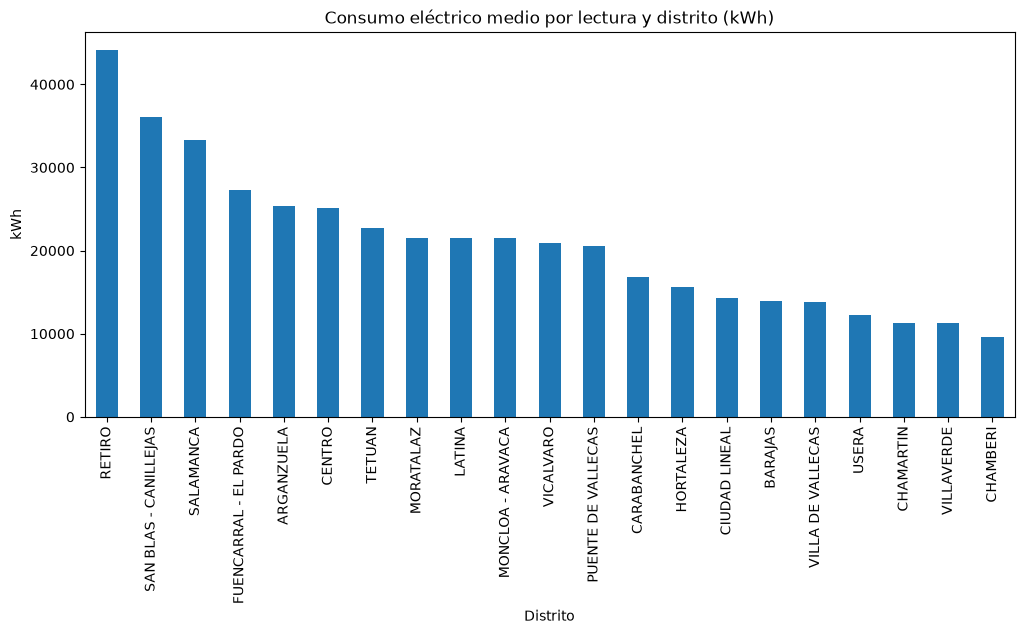

In [17]:
consumo_por_distrito = df_limpio2.groupby('DISTRITO')['CONSUMO'].mean().sort_values(ascending=False)
ax = consumo_por_distrito.plot(kind='bar', figsize=(12, 5), title='Consumo eléctrico medio por lectura y distrito (kWh)')
ax.set_xlabel('Distrito')
ax.set_ylabel('kWh')

### 8: Guardado del DataFrame de consumo de energia electrica de Madrid por distrito

In [18]:
df_limpio2.to_csv('consumo_energia_madrid_procesado.csv',index=False,sep=';',decimal=',')

### Limitaciones y siguientes pasos
- El z-score se calcula sobre **lecturas** (una fila por sensor y mes), no por edificio. Para comparar edificios convendría agregar primero el consumo por edificio y año, y normalizarlo por superficie o por uso.
- `pd.cut` usa los percentiles del propio conjunto, así que cada categoría agrupa aproximadamente el 20 % de las lecturas.
- Las lecturas de texto ("SIN DATOS…", "NO DATA") se tratan como nulos y se descartan.